In [12]:
# timm is pre-installed on Kaggle, but let's make sure it's up to date
!pip install timm --upgrade -q

import os, time, copy, random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix
import timm

# ── Config ──────────────────────────────────────────────────────
TRAIN_DIR     = '/kaggle/input/datasets/kedarsai/bird-species-classification-220-categories/Train'
TEST_DIR      = '/kaggle/input/datasets/kedarsai/bird-species-classification-220-categories/Test'
IMG_SIZE      = 224        # ViT-B/16 native size
BATCH_SIZE    = 32
NUM_WORKERS   = 2
SEED          = 42

PHASE1_EPOCHS = 5          # head only       (~6 min)
PHASE2_EPOCHS = 10         # last 4 blocks   (~20 min)
PHASE3_EPOCHS = 15         # full model      (~30 min)

PHASE1_LR     = 1e-3
PHASE2_LR     = 2e-4
PHASE3_LR     = 5e-5
MIXUP_ALPHA   = 0.3

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.backends.cudnn.benchmark = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")
print(f"GPU    : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")
print(f"timm   : {timm.__version__}")

Device : cuda
GPU    : Tesla P100-PCIE-16GB
timm   : 1.0.25


In [13]:
# ── ViT needs specific normalization (same as ImageNet) ──────────
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3,
                           saturation=0.2, hue=0.1),
    transforms.RandomGrayscale(p=0.05),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.2))
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

# ── Datasets ─────────────────────────────────────────────────────
full_train  = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
test_data   = datasets.ImageFolder(TEST_DIR,  transform=val_transforms)
CLASS_NAMES = full_train.classes
NUM_CLASSES = len(CLASS_NAMES)

val_size   = int(0.2 * len(full_train))
train_size = len(full_train) - val_size
train_data, val_split = random_split(
    full_train, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

# Val uses clean transforms
val_dataset = datasets.ImageFolder(TRAIN_DIR, transform=val_transforms)
val_data    = torch.utils.data.Subset(val_dataset, val_split.indices)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f"Classes : {NUM_CLASSES}")
print(f"Train   : {train_size} images")
print(f"Val     : {val_size} images")
print(f"Test    : {len(test_data)} images")

Classes : 200
Train   : 7532 images
Val     : 1882 images
Test    : 2374 images


In [14]:
def build_vit(num_classes, freeze_all=True):
    # ViT-B/16 pretrained on ImageNet-21k then finetuned on ImageNet-1k
    # This is the best free pretrained ViT available in timm
    model = timm.create_model(
        'vit_base_patch16_224',
        pretrained=True,
        num_classes=0          # remove default head → we add our own
    )

    if freeze_all:
        for param in model.parameters():
            param.requires_grad = False

    embed_dim = model.embed_dim  # 768 for ViT-B

    # Custom classification head
    model.head = nn.Sequential(
        nn.LayerNorm(embed_dim),
        nn.Dropout(p=0.3),
        nn.Linear(embed_dim, 512),
        nn.GELU(),
        nn.Dropout(p=0.2),
        nn.Linear(512, num_classes)
    )

    return model


model = build_vit(NUM_CLASSES, freeze_all=True).to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable params : {trainable:,} / {total:,}")
print(f"ViT embed dim    : {model.embed_dim}")
print(f"ViT depth        : {len(model.blocks)} transformer blocks")

Trainable params : 497,864 / 86,296,520
ViT embed dim    : 768
ViT depth        : 12 transformer blocks


In [15]:
# ── Mixup ────────────────────────────────────────────────────────
def mixup_batch(imgs, labels, alpha=MIXUP_ALPHA):
    lam   = np.random.beta(alpha, alpha)
    idx   = torch.randperm(imgs.size(0)).to(device)
    mixed = lam * imgs + (1 - lam) * imgs[idx]
    return mixed, labels, labels[idx], lam

def mixup_loss(criterion, preds, y_a, y_b, lam):
    return lam * criterion(preds, y_a) + (1 - lam) * criterion(preds, y_b)


# ── Train one epoch ──────────────────────────────────────────────
def train_epoch(model, loader, criterion, optimizer, use_mixup=True):
    model.train()
    total_loss, correct, total = 0.0, 0.0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()

        if use_mixup:
            imgs, y_a, y_b, lam = mixup_batch(imgs, labels)
            preds = model(imgs)
            loss  = mixup_loss(criterion, preds, y_a, y_b, lam)
            correct += (lam * (preds.argmax(1) == y_a).float()
                      + (1-lam) * (preds.argmax(1) == y_b).float()).sum().item()
        else:
            preds   = model(imgs)
            loss    = criterion(preds, labels)
            correct += (preds.argmax(1) == labels).sum().item()

        loss.backward()
        # ── Gradient clipping (critical for ViT stability) ───────
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        total      += imgs.size(0)
    return total_loss / total, correct / total


# ── Evaluate ─────────────────────────────────────────────────────
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds      = model(imgs)
            loss       = criterion(preds, labels)
            total_loss += loss.item() * imgs.size(0)
            correct    += (preds.argmax(1) == labels).sum().item()
            total      += imgs.size(0)
    return total_loss / total, correct / total

In [16]:
criterion    = nn.CrossEntropyLoss(label_smoothing=0.1)
history      = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
best_val_acc = 0.0
best_weights = None

def run_phase(name, epochs, optimizer, scheduler, use_mixup=False):
    global best_val_acc, best_weights
    print(f"\n{'='*65}")
    print(f" {name}")
    print(f"{'='*65}")
    for epoch in range(epochs):
        t0 = time.time()
        tr_loss, tr_acc = train_epoch(model, train_loader, criterion,
                                      optimizer, use_mixup=use_mixup)
        vl_loss, vl_acc = eval_epoch(model, val_loader, criterion)
        if scheduler:
            scheduler.step()

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)

        flag = ""
        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            best_weights = copy.deepcopy(model.state_dict())
            flag = "  ✅"

        print(f"Epoch {epoch+1:2d}/{epochs} | "
              f"Train {tr_acc*100:.2f}% | Val {vl_acc*100:.2f}% | "
              f"Loss {vl_loss:.4f} | {time.time()-t0:.0f}s{flag}")

    print(f"\n  Best so far: {best_val_acc*100:.2f}%")

In [17]:
optimizer = optim.Adam(model.head.parameters(), lr=PHASE1_LR)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=PHASE1_EPOCHS)

run_phase("PHASE 1 — Head only (no Mixup)",
          PHASE1_EPOCHS, optimizer, scheduler, use_mixup=False)


 PHASE 1 — Head only (no Mixup)
Epoch  1/5 | Train 36.88% | Val 67.27% | Loss 1.9608 | 78s  ✅
Epoch  2/5 | Train 63.67% | Val 73.75% | Loss 1.7552 | 67s  ✅
Epoch  3/5 | Train 69.85% | Val 77.68% | Loss 1.6587 | 67s  ✅
Epoch  4/5 | Train 75.61% | Val 81.83% | Loss 1.5746 | 67s  ✅
Epoch  5/5 | Train 78.93% | Val 83.53% | Loss 1.5412 | 68s  ✅

  Best so far: 83.53%


In [18]:
# ViT-B has 12 transformer blocks — unfreeze only the last 4
# This preserves low-level features, adapts high-level ones
NUM_BLOCKS  = len(model.blocks)   # 12
UNFREEZE_N  = 4                   # last 4 blocks

for i, block in enumerate(model.blocks):
    if i >= NUM_BLOCKS - UNFREEZE_N:
        for param in block.parameters():
            param.requires_grad = True

# Also unfreeze the norm layer
for param in model.norm.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable params now: {trainable:,}")

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=PHASE2_LR, weight_decay=1e-4
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=PHASE2_EPOCHS)

run_phase("PHASE 2 — Last 4 blocks + Mixup",
          PHASE2_EPOCHS, optimizer, scheduler, use_mixup=True)

Trainable params now: 28,850,888

 PHASE 2 — Last 4 blocks + Mixup
Epoch  1/10 | Train 58.97% | Val 80.13% | Loss 1.5909 | 87s
Epoch  2/10 | Train 65.32% | Val 81.83% | Loss 1.5282 | 88s
Epoch  3/10 | Train 67.98% | Val 81.99% | Loss 1.4943 | 88s
Epoch  4/10 | Train 69.85% | Val 81.67% | Loss 1.5065 | 88s
Epoch  5/10 | Train 73.84% | Val 83.00% | Loss 1.4639 | 88s
Epoch  6/10 | Train 77.74% | Val 83.53% | Loss 1.4308 | 88s
Epoch  7/10 | Train 76.46% | Val 83.74% | Loss 1.4097 | 88s  ✅
Epoch  8/10 | Train 79.64% | Val 84.91% | Loss 1.3971 | 88s  ✅
Epoch  9/10 | Train 78.69% | Val 85.28% | Loss 1.3812 | 88s  ✅
Epoch 10/10 | Train 82.18% | Val 85.28% | Loss 1.3785 | 88s

  Best so far: 85.28%


In [19]:
# Unfreeze everything including patch embeddings
for param in model.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable params now: {trainable:,}  (full model)")

optimizer = optim.AdamW(
    model.parameters(),
    lr=PHASE3_LR,
    weight_decay=1e-4
)
# Warm restarts help ViT escape local minima
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=8, T_mult=1, eta_min=1e-7
)

run_phase("PHASE 3 — Full fine-tune + Mixup",
          PHASE3_EPOCHS, optimizer, scheduler, use_mixup=True)

# Load best checkpoint
model.load_state_dict(best_weights)
print(f"\n🎯 Best Val Accuracy: {best_val_acc*100:.2f}%")

Trainable params now: 86,296,520  (full model)

 PHASE 3 — Full fine-tune + Mixup
Epoch  1/15 | Train 77.23% | Val 82.41% | Loss 1.4531 | 152s
Epoch  2/15 | Train 80.12% | Val 81.40% | Loss 1.4753 | 151s
Epoch  3/15 | Train 80.64% | Val 83.00% | Loss 1.4522 | 152s
Epoch  4/15 | Train 81.84% | Val 82.25% | Loss 1.4695 | 152s
Epoch  5/15 | Train 82.18% | Val 83.42% | Loss 1.4204 | 151s
Epoch  6/15 | Train 84.26% | Val 84.17% | Loss 1.3976 | 151s
Epoch  7/15 | Train 82.68% | Val 85.28% | Loss 1.3790 | 151s
Epoch  8/15 | Train 81.78% | Val 85.12% | Loss 1.3703 | 151s
Epoch  9/15 | Train 80.38% | Val 82.15% | Loss 1.4656 | 151s
Epoch 10/15 | Train 80.85% | Val 82.47% | Loss 1.4714 | 152s
Epoch 11/15 | Train 79.79% | Val 82.52% | Loss 1.4464 | 151s
Epoch 12/15 | Train 84.78% | Val 83.53% | Loss 1.4492 | 152s
Epoch 13/15 | Train 83.44% | Val 84.54% | Loss 1.4205 | 152s
Epoch 14/15 | Train 85.07% | Val 84.64% | Loss 1.3990 | 152s
Epoch 15/15 | Train 81.22% | Val 84.91% | Loss 1.3788 | 152s

  

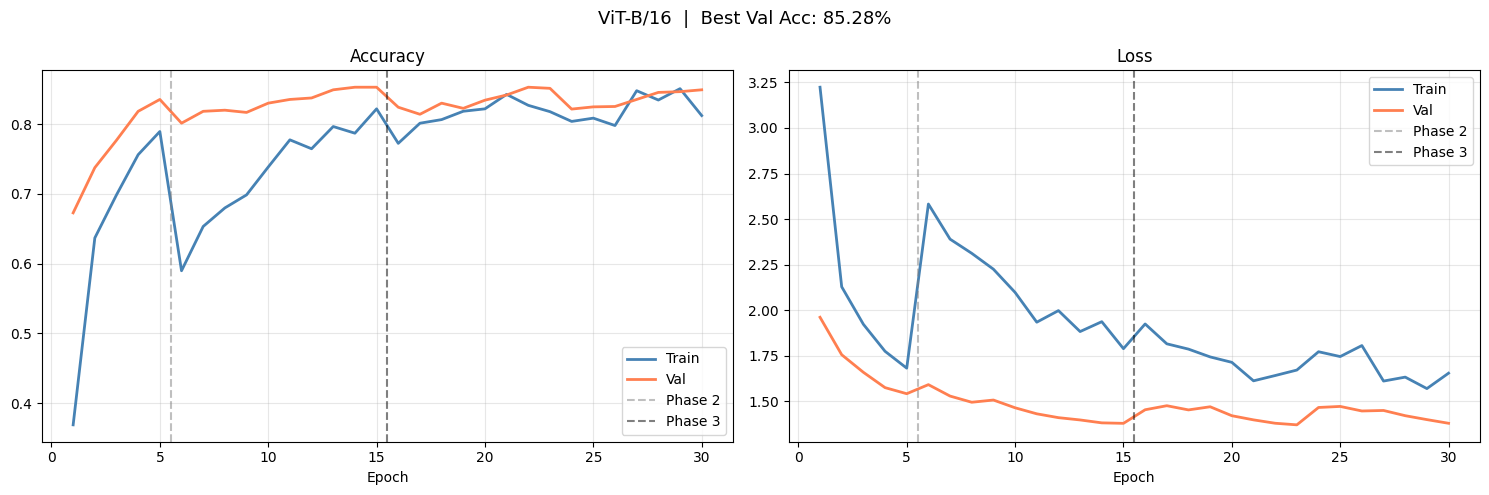

In [20]:
total_ep = PHASE1_EPOCHS + PHASE2_EPOCHS + PHASE3_EPOCHS
ep = range(1, total_ep + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

for ax, keys, title in [
    (ax1, ('train_acc', 'val_acc'),   'Accuracy'),
    (ax2, ('train_loss', 'val_loss'), 'Loss')
]:
    ax.plot(ep, history[keys[0]], label='Train', color='steelblue', lw=2)
    ax.plot(ep, history[keys[1]], label='Val',   color='coral',     lw=2)
    ax.axvline(PHASE1_EPOCHS + 0.5,
               color='gray', ls='--', alpha=0.5, label='Phase 2')
    ax.axvline(PHASE1_EPOCHS + PHASE2_EPOCHS + 0.5,
               color='black', ls='--', alpha=0.5, label='Phase 3')
    ax.set_title(title); ax.set_xlabel('Epoch')
    ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle(f'ViT-B/16  |  Best Val Acc: {best_val_acc*100:.2f}%', fontsize=13)
plt.tight_layout()
plt.show()

In [21]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        preds = model(imgs.to(device)).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc = (all_preds == all_labels).mean()
print(f"🎯 Test Accuracy  : {test_acc*100:.2f}%")

# Top-5
def top5_accuracy(model, loader):
    model.eval(); correct = total = 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            _, top5 = model(imgs).topk(5, dim=1)
            correct += top5.eq(labels.view(-1,1).expand_as(top5)).any(dim=1).sum().item()
            total   += labels.size(0)
    return correct / total

top5 = top5_accuracy(model, test_loader)
print(f"🎯 Top-5 Accuracy : {top5*100:.2f}%")

# Worst performing classes (most confused)
per_class_acc = {}
for cls_idx, cls_name in enumerate(CLASS_NAMES):
    mask = all_labels == cls_idx
    if mask.sum() > 0:
        per_class_acc[cls_name] = (all_preds[mask] == cls_idx).mean()

worst = sorted(per_class_acc.items(), key=lambda x: x[1])[:10]
print("\n10 hardest species:")
for name, acc in worst:
    print(f"  {name:<40} {acc*100:.1f}%")

🎯 Test Accuracy  : 84.88%
🎯 Top-5 Accuracy : 96.84%

10 hardest species:
  Herring_Gull                             25.0%
  Fish_Crow                                33.3%
  Forsters_Tern                            33.3%
  Least_Flycatcher                         33.3%
  American_Crow                            50.0%
  California_Gull                          50.0%
  Common_Tern                              50.0%
  Elegant_Tern                             50.0%
  Glaucous_winged_Gull                     50.0%
  Loggerhead_Shrike                        50.0%


Model saved ✅


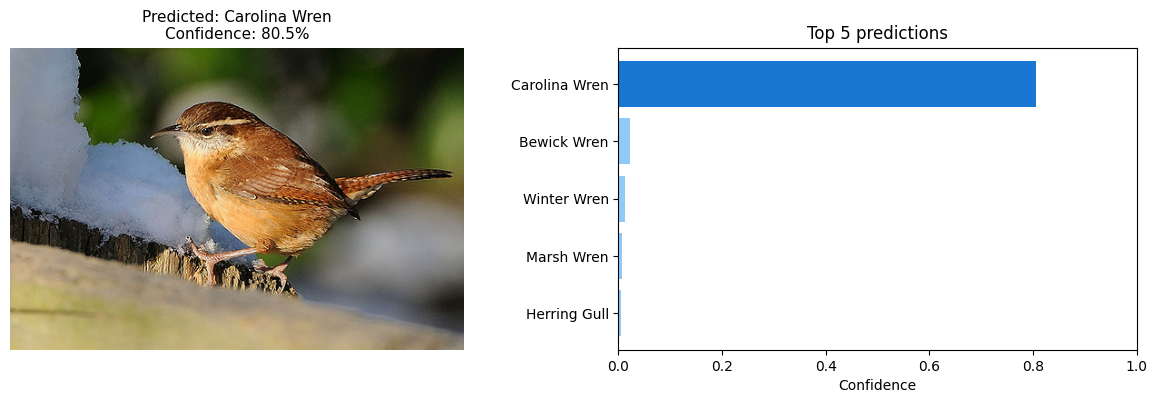

In [27]:
torch.save(model.state_dict(), 'bird_vit_b16_final.pth')
print("Model saved ✅")

# ── Predict any single image ─────────────────────────────────────
def predict(image_path, top_k=5):
    model.eval()
    img    = Image.open(image_path).convert('RGB')
    tensor = val_transforms(img).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = torch.softmax(model(tensor), dim=1).squeeze()
    top_probs, top_idxs = probs.topk(top_k)
    top_probs = top_probs.cpu().numpy()
    top_idxs  = top_idxs.cpu().numpy()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.imshow(img); ax1.axis('off')
    ax1.set_title(f"Predicted: {CLASS_NAMES[top_idxs[0]].replace('_',' ')}\n"
                  f"Confidence: {top_probs[0]*100:.1f}%", fontsize=11)

    colors = ['#1976D2' if i == 0 else '#90CAF9' for i in range(top_k)]
    labels = [CLASS_NAMES[i].replace('_', ' ') for i in top_idxs]
    ax2.barh(labels[::-1], top_probs[::-1], color=colors[::-1])
    ax2.set_xlabel('Confidence'); ax2.set_xlim(0, 1)
    ax2.set_title('Top 5 predictions')
    plt.tight_layout()
    plt.show()

# Try on one test image
cls    = CLASS_NAMES[42]
folder = os.path.join(TEST_DIR, cls)
predict(os.path.join(folder, os.listdir(folder)[0]))
